# Load statistics and plot mean + 16-84 percentile ranges

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import sys
import os

_scripts = Path.cwd() / "code"
if not _scripts.exists():
    _scripts = Path.cwd().parent / "code"
sys.path.insert(0, str(_scripts.resolve()))

import data_loader
import utils

%load_ext autoreload
%autoreload 2

## Config

In [2]:
n_cosmo_max = 100

tag_params_train = '_p5_n10000'
tag_params_coverage = '_coverage_p5_n1000'
tag_params_shame_p0 = '_shame_p0_n1000'
tag_mock_shame = '_nbar0.00022'

tag_biasparams_fixed = '_biasshame_p0_n1'
tag_biasparams_fixed_bl0 = '_biasshamebl0_p0_n1'
tag_biasparams_nest = '_biasnest_p4_n320000'
tag_biasparams_cov = '_biascoverage_p4_n1000'

# Bias+noise variant (used for the green “varying bias+noise” curves)
tag_biasparams_nest_noise = '_biasnoisenest_p9_n320000'
tag_biasparams_cov_noise = '_biasnoisecoverage_p9_n1000'
tag_noise = '_noise_unit_p5_n10000'
tag_noise_coverage = '_noise_unit_coverage_p5_n1000'

# Plot colors (tunable)
COLOR_FIXED_BIAS = 'purple'
COLOR_VARYING_BIAS = 'blue'
COLOR_VARYING_BIAS_NOISE = 'green'
COLOR_FIXED_COSMO = 'magenta'

# Plot styles (tunable)
ALPHA_BAND = 0.20
ALPHA_BAND_HATCH = 0.16
SHAME_LINEWIDTH = 2.2
SHAME_LINESTYLE = '--'

bias_param_cols = ['b1', 'b2', 'bs2', 'bl']

param_dict_shame = data_loader.load_params_ood('shame', tag_mock_shame)
bias_vector_shame = [param_dict_shame[name] for name in utils.biasparam_names_ordered]
print('Shame bias params:', dict(zip(utils.biasparam_names_ordered, bias_vector_shame)))


def stats_summary(arr):
    return (np.nanmean(arr, axis=0),
            np.nanpercentile(arr, 16, axis=0),
            np.nanpercentile(arr, 84, axis=0))


def plot_fill(ax, x, mean, p16, p84, color, label):
    ax.fill_between(x, p16, p84, color=color, alpha=ALPHA_BAND, label=f'{label} (16-84%)')
    ax.plot(x, mean, color=color, label=f'{label} (mean)')


def plot_fill_hatch(ax, x, mean, p16, p84, color, label):
    """Same color as plot_fill but dashed mean and cross-hatch for 16-84% band."""
    ax.fill_between(x, p16, p84, color=color, alpha=ALPHA_BAND_HATCH, hatch='xx', label=f'{label} (16-84%)')
    ax.plot(x, mean, color=color, linestyle='--', label=f'{label} (mean)')


def format_ax(ax, title, xlabel, ylabel, xlog=True, ylog=True):
    if xlog:
        ax.set_xscale('log')
    if ylog:
        ax.set_yscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(loc='best', fontsize=8)
    ax.set_title(title)

Shame bias params: {'b1': 0.47410742, 'b2': 0.12701492, 'bs2': -0.33881766, 'bl': -0.82443643}


## Check nested bias params

In [3]:
fn_nest_params = '../data/params/params_lh_biasnest_p4_n320000.txt'
df_nest = pd.read_csv(fn_nest_params, index_col=0)
print(f"Shape: {df_nest.shape}")
print(f"Columns: {df_nest.columns.tolist()}")
print(f"\nFirst 10 rows:")
df_nest.head(10)

Shape: (320000, 6)
Columns: ['b1', 'b2', 'bs2', 'bl', 'idx_cosmo', 'nest_layer']

First 10 rows:


,b1,b2,bs2,bl,idx_cosmo,nest_layer
0,-0.410989,-1.639792,1.339203,-3.902996,0,0
1,2.626207,1.480202,1.150603,6.707007,1,0
2,-0.084996,-1.894388,1.278801,-2.257958,2,0
3,1.867210,-0.830590,-1.893995,-6.559939,3,0
4,0.276207,-0.861799,-1.481599,1.676001,4,0
5,0.170010,-0.322197,0.846001,-8.614969,5,0
6,0.516006,0.437403,1.319809,-1.120948,6,0
7,0.470004,-0.954791,1.993212,1.246019,7,0
8,-0.119195,-1.729792,-0.589590,-6.786964,8,0
9,2.195610,-0.367798,-1.875194,4.209050,9,0


In [4]:
expected_bounds = {
    'b1':  [-1.0, 3.0],
    'b2':  [-2.0, 2.0],
    'bs2': [-2.0, 2.0],
    'bl':  [-10.0, 10.0],
}

print("Bounds check:")
for col in bias_param_cols:
    lo, hi = expected_bounds[col]
    actual_min, actual_max = df_nest[col].min(), df_nest[col].max()
    within = (actual_min >= lo) and (actual_max <= hi)
    covers = (actual_max - actual_min) > 0.99 * (hi - lo)
    status = "PASS" if (within and covers) else "FAIL"
    print(f"  {col:4s}: [{actual_min:+.6f}, {actual_max:+.6f}]  expected [{lo}, {hi}]  "
          f"within={within}  covers_99%={covers}  {status}")
    assert within, f"{col} outside expected bounds!"
    assert covers, f"{col} does not cover at least 99% of expected range!"

print("\nAll bounds checks passed.")
print("\nBasic stats:")
df_nest[bias_param_cols].describe()

Bounds check:
  b1  : [-1.000000, +2.999997]  expected [-1.0, 3.0]  within=True  covers_99%=True  PASS
  b2  : [-1.999990, +1.999998]  expected [-2.0, 2.0]  within=True  covers_99%=True  PASS
  bs2 : [-1.999998, +1.999990]  expected [-2.0, 2.0]  within=True  covers_99%=True  PASS
  bl  : [-9.999949, +9.999963]  expected [-10.0, 10.0]  within=True  covers_99%=True  PASS

All bounds checks passed.

Basic stats:


,b1,b2,bs2,bl
count,320000.000000,3.200000e+05,3.200000e+05,3.200000e+05
mean,1.000000,8.395680e-10,7.511721e-09,-1.477290e-08
std,1.154702,1.154702e+00,1.154702e+00,5.773512e+00
min,-1.000000,-1.999990e+00,-1.999998e+00,-9.999949e+00
25%,0.000004,-9.999995e-01,-9.999940e-01,-5.000007e+00
50%,1.000000,-1.296251e-06,2.831097e-06,1.392974e-05
75%,1.999996,9.999984e-01,9.999945e-01,4.999980e+00
max,2.999997,1.999998e+00,1.999990e+00,9.999963e+00


In [5]:
print("Metadata:")
print(f"  idx_cosmo unique values: {df_nest['idx_cosmo'].nunique()} (expect 10000)")
print(f"  idx_cosmo range: [{df_nest['idx_cosmo'].min()}, {df_nest['idx_cosmo'].max()}]")
print(f"  nest_layer unique values: {sorted(df_nest['nest_layer'].unique())}")
print(f"\n  Rows per nest_layer:")
print(df_nest['nest_layer'].value_counts().sort_index())
print(f"\n  Rows per cosmo (should all be 32):")
cosmo_counts = df_nest['idx_cosmo'].value_counts()
print(f"    min: {cosmo_counts.min()}, max: {cosmo_counts.max()}, mean: {cosmo_counts.mean():.1f}")

Metadata:
  idx_cosmo unique values: 10000 (expect 10000)
  idx_cosmo range: [0, 9999]
  nest_layer unique values: [0, 1, 2, 3, 4, 5]

  Rows per nest_layer:
nest_layer
0     10000
1     10000
2     20000
3     40000
4     80000
5    160000
Name: count, dtype: int64

  Rows per cosmo (should all be 32):
    min: 32, max: 32, mean: 32.0


In [6]:
n_cosmo = 10000
n_factors = [1, 2, 4, 8, 16, 32]
print("Nesting check (cumulative rows per layer):")
for j in range(len(n_factors)):
    subset = df_nest[df_nest['nest_layer'] <= j]
    expected = n_cosmo * n_factors[j]
    print(f"  nest_layer <= {j}: {len(subset)} rows (expected {expected}, factor={n_factors[j]}x)")

print("\nNesting of cosmo sets:")
for j in range(len(n_factors) - 1):
    set_j = set(zip(df_nest[df_nest['nest_layer'] <= j].index,
                     df_nest[df_nest['nest_layer'] <= j]['idx_cosmo']))
    set_j1 = set(zip(df_nest[df_nest['nest_layer'] <= j+1].index,
                      df_nest[df_nest['nest_layer'] <= j+1]['idx_cosmo']))
    print(f"  layer<={j} subset of layer<={j+1}: {set_j.issubset(set_j1)}")

Nesting check (cumulative rows per layer):
  nest_layer <= 0: 10000 rows (expected 10000, factor=1x)
  nest_layer <= 1: 20000 rows (expected 20000, factor=2x)
  nest_layer <= 2: 40000 rows (expected 40000, factor=4x)
  nest_layer <= 3: 80000 rows (expected 80000, factor=8x)
  nest_layer <= 4: 160000 rows (expected 160000, factor=16x)
  nest_layer <= 5: 320000 rows (expected 320000, factor=32x)

Nesting of cosmo sets:
  layer<=0 subset of layer<=1: True
  layer<=1 subset of layer<=2: True
  layer<=2 subset of layer<=3: True
  layer<=3 subset of layer<=4: True
  layer<=4 subset of layer<=5: True


# Noiseless

## P(k)

In [7]:
# SHAMe mock PK
k_shame_pk, y_shame_pk, _ = data_loader.load_data_shame('pk', tag_mock_shame)

Loaded pk with shape (32,)


In [8]:
# Training: fixed bias (shame bias on all cosmologies)
k_pnn_train_fixed, pks_train_fixed, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_train, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pnn_tf, p16_pnn_tf, p84_pnn_tf = stats_summary(pks_train_fixed)
print(f"Training fixed bias: {pks_train_fixed.shape}")

# Training: varying bias (nested, all 32 layers)
k_pnn_train_vary, pks_train_vary, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_train, tag_biasparams_nest, n_cosmo_max=n_cosmo_max)
mean_pnn_tv, p16_pnn_tv, p84_pnn_tv = stats_summary(pks_train_vary)
print(f"Training varying bias: {pks_train_vary.shape}")

# Training: varying bias+noise (nested, all 32 layers)
k_pk_train_vary_noise, pks_train_vary_noise, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_train, tag_biasparams_nest_noise, tag_noise=tag_noise,
    n_cosmo_max=n_cosmo_max)
mean_pk_tv_noise, p16_pk_tv_noise, p84_pk_tv_noise = stats_summary(pks_train_vary_noise)
print(f"Training varying bias+noise: {pks_train_vary_noise.shape}")

dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000


Found 10000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training fixed bias: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnest_p4_n320000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Found 10000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training varying bias: (3200, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 10000 diff cosmo pks in /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training varying bias+noise:

In [9]:
# Coverage: fixed bias
k_pnn_cov_fixed, pks_cov_fixed, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_coverage, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pnn_cf, p16_pnn_cf, p84_pnn_cf = stats_summary(pks_cov_fixed)
print(f"Coverage fixed bias: {pks_cov_fixed.shape}")

# Coverage: varying bias (biascoverage)
k_pnn_cov_vary, pks_cov_vary, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_coverage, tag_biasparams_cov, n_cosmo_max=n_cosmo_max)
mean_pnn_cv, p16_pnn_cv, p84_pnn_cv = stats_summary(pks_cov_vary)
print(f"Coverage varying bias: {pks_cov_vary.shape}")

# Coverage: varying bias+noise (same bias tag, different cosmology set)
k_pk_cov_vary_noise, pks_cov_vary_noise, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_coverage, tag_biasparams_cov_noise, tag_noise=tag_noise_coverage,
    n_cosmo_max=n_cosmo_max)
mean_pk_cv_noise, p16_pk_cv_noise, p84_pk_cv_noise = stats_summary(pks_cov_vary_noise)
print(f"Coverage varying bias+noise: {pks_cov_vary_noise.shape}")

#Fixed cosmology (shame_p0)
k_pnn_shame, pks_shame_p0, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_shame_p0, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pnn_sp, p16_pnn_sp, p84_pnn_sp = stats_summary(pks_shame_p0)
print(f"Fixed cosmology: {pks_shame_p0.shape}")

dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_coverage_p5_n1000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Found 1000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Coverage fixed bias: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_coverage_p5_n1000_biascoverage_p4_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Found 1000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Coverage varying bias: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_coverage_p5_n1000_b

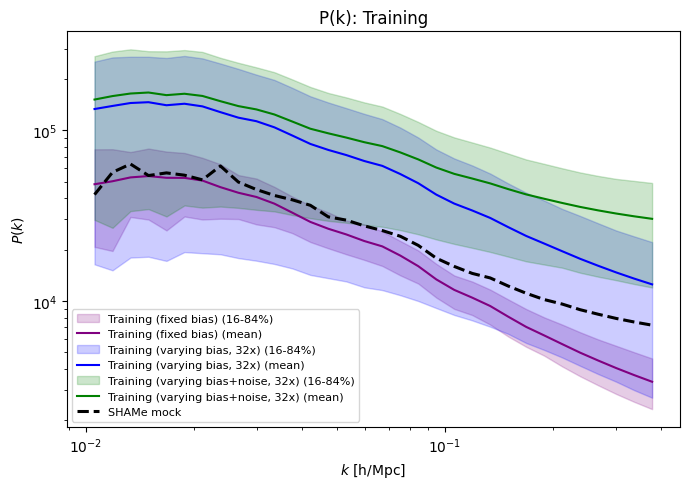

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
# Legend order: fixed bias -> varying bias -> varying bias+noise
plot_fill(ax, k_pnn_train_fixed, mean_pnn_tf, p16_pnn_tf, p84_pnn_tf,
          COLOR_FIXED_BIAS, 'Training (fixed bias)')
plot_fill(ax, k_pnn_train_vary, mean_pnn_tv, p16_pnn_tv, p84_pnn_tv,
          COLOR_VARYING_BIAS, 'Training (varying bias, 32x)')
plot_fill(ax, k_pk_train_vary_noise, mean_pk_tv_noise, p16_pk_tv_noise, p84_pk_tv_noise,
          COLOR_VARYING_BIAS_NOISE, 'Training (varying bias+noise, 32x)')
ax.plot(k_shame_pk, y_shame_pk, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'P(k): Training', r'$k$ [h/Mpc]', r'$P(k)$')
plt.tight_layout()
plt.show()

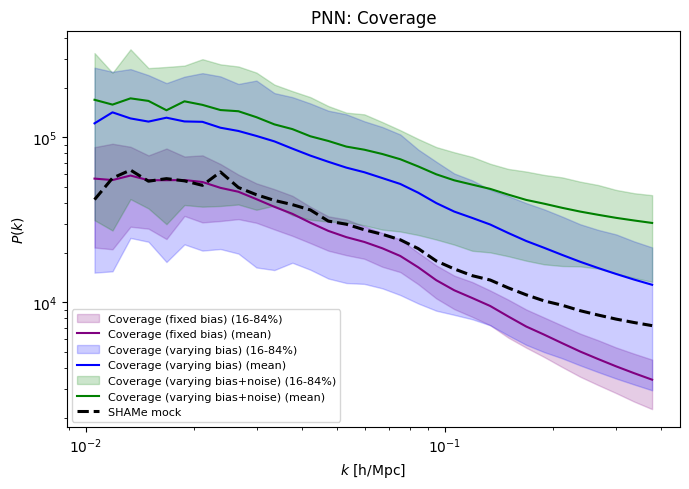

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
# Legend order: fixed bias -> varying bias -> varying bias+noise
plot_fill(ax, k_pnn_cov_fixed, mean_pnn_cf, p16_pnn_cf, p84_pnn_cf,
          COLOR_FIXED_BIAS, 'Coverage (fixed bias)')
plot_fill(ax, k_pnn_cov_vary, mean_pnn_cv, p16_pnn_cv, p84_pnn_cv,
          COLOR_VARYING_BIAS, 'Coverage (varying bias)')
plot_fill(ax, k_pk_cov_vary_noise, mean_pk_cv_noise, p16_pk_cv_noise, p84_pk_cv_noise,
          COLOR_VARYING_BIAS_NOISE, 'Coverage (varying bias+noise)')
ax.plot(k_shame_pk, y_shame_pk, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'PNN: Coverage', r'$k$ [h/Mpc]', r'$P(k)$')
plt.tight_layout()
plt.show()

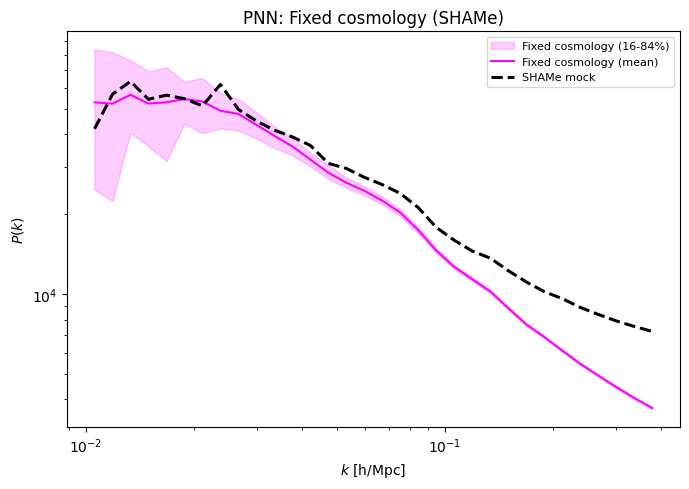

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, k_pnn_shame, mean_pnn_sp, p16_pnn_sp, p84_pnn_sp,
          COLOR_FIXED_COSMO, 'Fixed cosmology')
ax.plot(k_shame_pk, y_shame_pk, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'PNN: Fixed cosmology (SHAMe)', r'$k$ [h/Mpc]', r'$P(k)$')
plt.tight_layout()
plt.show()

## P_gm(k)

In [13]:
# SHAMe mock PGM
k_shame_pgm, y_shame_pgm, _ = data_loader.load_data_shame('pgm', tag_mock_shame)

Loaded pgm with shape (32,)


In [14]:
# Training: fixed bias (PGM from PNNs with shame bias, or precomputed if available)
k_pgm_train_fixed, pgms_train_fixed, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_train, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pgm_tf, p16_pgm_tf, p84_pgm_tf = stats_summary(pgms_train_fixed)
print(f"Training fixed bias PGM: {pgms_train_fixed.shape}")

# Training: varying bias (precomputed, bx=1)
k_pgm_train_vary, pgms_train_vary, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_train, tag_biasparams_nest, bx=1, n_cosmo_max=n_cosmo_max)
mean_pgm_tv, p16_pgm_tv, p84_pgm_tv = stats_summary(pgms_train_vary)
print(f"Training varying bias PGM: {pgms_train_vary.shape}")

# Training: varying bias+noise (nested, bx=1)
k_pgm_train_vary_noise, pgms_train_vary_noise, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_train, tag_biasparams_nest_noise, tag_noise=tag_noise, 
    bx=1, n_cosmo_max=n_cosmo_max)
mean_pgm_tv_noise, p16_pgm_tv_noise, p84_pgm_tv_noise = stats_summary(pgms_train_vary_noise)
print(f"Training varying bias+noise PGM: {pgms_train_vary_noise.shape}")

dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000


Found 10000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training fixed bias PGM: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnest_p4_n320000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Found 10000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training varying bias PGM: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 10000 diff cosmo pgms in /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training var

In [15]:
# Coverage: fixed bias (PGM from PNNs with shame bias, or precomputed if available)
k_pgm_cov_fixed, pgms_cov_fixed, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_coverage, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pgm_cf, p16_pgm_cf, p84_pgm_cf = stats_summary(pgms_cov_fixed)
print(f"Coverage fixed bias PGM: {pgms_cov_fixed.shape}")

# Coverage: varying bias (precomputed)
k_pgm_cov_vary, pgms_cov_vary, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_coverage, tag_biasparams_cov, n_cosmo_max=n_cosmo_max)
mean_pgm_cv, p16_pgm_cv, p84_pgm_cv = stats_summary(pgms_cov_vary)
print(f"Coverage varying bias PGM: {pgms_cov_vary.shape}")

# Coverage: varying bias+noise (nested)
k_pgm_cov_vary_noise, pgms_cov_vary_noise, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_coverage, tag_biasparams_cov_noise, tag_noise=tag_noise_coverage,
    n_cosmo_max=n_cosmo_max)
mean_pgm_cv_noise, p16_pgm_cv_noise, p84_pgm_cv_noise = stats_summary(pgms_cov_vary_noise)
print(f"Coverage varying bias+noise PGM: {pgms_cov_vary_noise.shape}")

# Fixed cosmology (precomputed)
k_pgm_shame, pgms_shame_p0, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_shame_p0, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pgm_sp, p16_pgm_sp, p84_pgm_sp = stats_summary(pgms_shame_p0)
print(f"Fixed cosmology PGM: {pgms_shame_p0.shape}")

# Fixed cosmology with bl=0 (recombine PNNs into PGMs via tag_biasparams_fixed_bl0)
_, pgms_shame_p0_bl0, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_shame_p0, tag_biasparams_fixed_bl0, n_cosmo_max=n_cosmo_max)
mean_pgm_sp_bl0, p16_pgm_sp_bl0, p84_pgm_sp_bl0 = stats_summary(pgms_shame_p0_bl0)
print(f"Fixed cosmology PGM (bl=0): {pgms_shame_p0_bl0.shape}")

dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_coverage_p5_n1000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Found 1000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)


Coverage fixed bias PGM: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_coverage_p5_n1000_biascoverage_p4_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Found 1000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Coverage varying bias PGM: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000
Found 1000 diff cosmo pgms in /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Coverage varying bias+noise PGM: (100, 32)
dir_statistics: /scratch/kstore

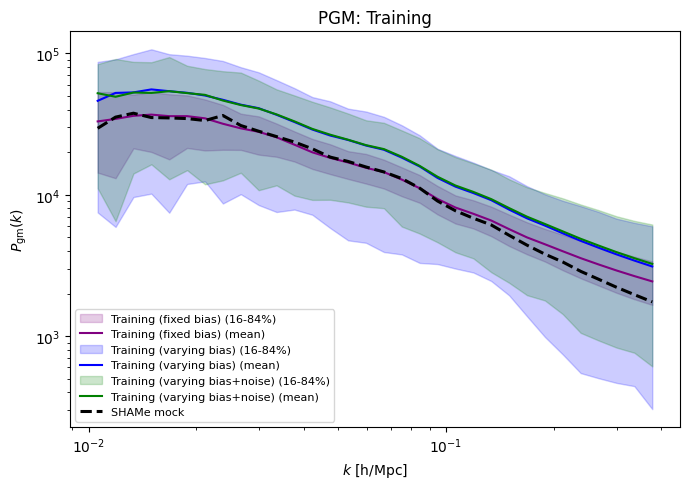

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
# Legend order: fixed bias -> varying bias -> varying bias+noise
plot_fill(ax, k_pgm_train_fixed, mean_pgm_tf, p16_pgm_tf, p84_pgm_tf,
          COLOR_FIXED_BIAS, 'Training (fixed bias)')
plot_fill(ax, k_pgm_train_vary, mean_pgm_tv, p16_pgm_tv, p84_pgm_tv,
          COLOR_VARYING_BIAS, 'Training (varying bias)')
plot_fill(ax, k_pgm_train_vary_noise, mean_pgm_tv_noise, p16_pgm_tv_noise, p84_pgm_tv_noise,
          COLOR_VARYING_BIAS_NOISE, 'Training (varying bias+noise)')
ax.plot(k_shame_pgm, y_shame_pgm, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'PGM: Training', r'$k$ [h/Mpc]', r'$P_\mathrm{gm}(k)$')
plt.tight_layout()
plt.show()

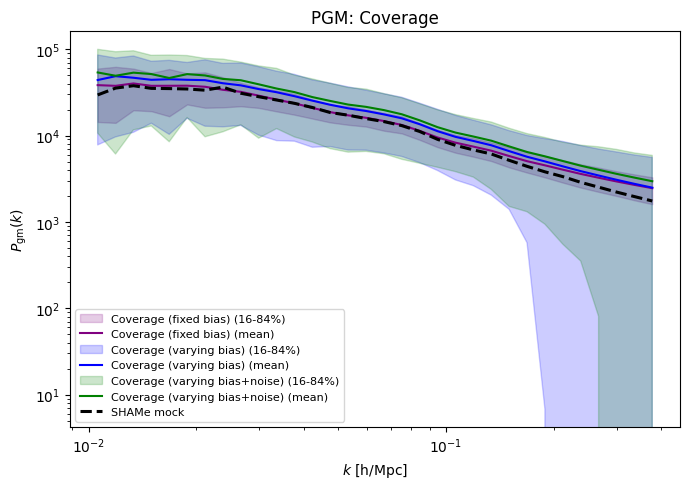

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
# Legend order: fixed bias -> varying bias -> varying bias+noise
plot_fill(ax, k_pgm_cov_fixed, mean_pgm_cf, p16_pgm_cf, p84_pgm_cf,
          COLOR_FIXED_BIAS, 'Coverage (fixed bias)')
plot_fill(ax, k_pgm_cov_vary, mean_pgm_cv, p16_pgm_cv, p84_pgm_cv,
          COLOR_VARYING_BIAS, 'Coverage (varying bias)')
plot_fill(ax, k_pgm_cov_vary_noise, mean_pgm_cv_noise, p16_pgm_cv_noise, p84_pgm_cv_noise,
          COLOR_VARYING_BIAS_NOISE, 'Coverage (varying bias+noise)')
ax.plot(k_shame_pgm, y_shame_pgm, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'PGM: Coverage', r'$k$ [h/Mpc]', r'$P_\mathrm{gm}(k)$')
plt.tight_layout()
plt.show()

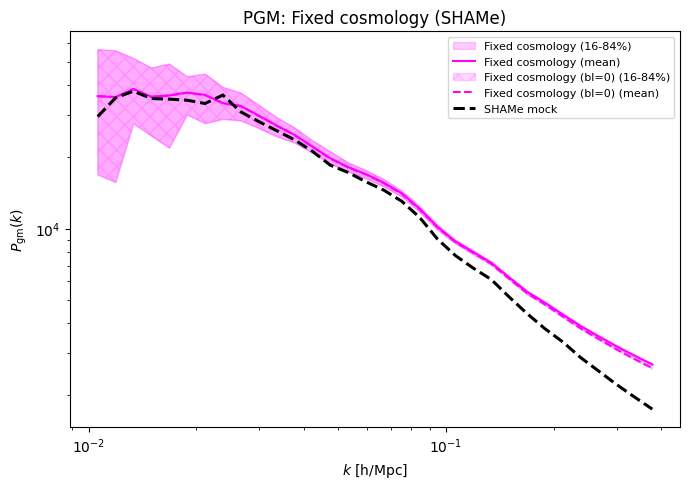

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, k_pgm_shame, mean_pgm_sp, p16_pgm_sp, p84_pgm_sp,
          COLOR_FIXED_COSMO, 'Fixed cosmology')
plot_fill_hatch(ax, k_pgm_shame, mean_pgm_sp_bl0, p16_pgm_sp_bl0, p84_pgm_sp_bl0,
                COLOR_FIXED_COSMO, 'Fixed cosmology (bl=0)')
ax.plot(k_shame_pgm, y_shame_pgm, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'PGM: Fixed cosmology (SHAMe)', r'$k$ [h/Mpc]', r'$P_\mathrm{gm}(k)$')
plt.tight_layout()
plt.show()

## Bispectrum

For the bispectrum, we only have precomputed (unlike pnn case) that we have only run on the varying set, so don't have the fixed versions (which are free to get in the pnn and pgm cases as we can just recombine the pnns)

In [19]:
# SHAMe mock bispectrum
k_shame_bispec, y_shame_bispec, _ = data_loader.load_data_shame('bispec', tag_mock_shame)

Loaded bispec with shape (203,)


In [20]:
# Training: varying bias (precomputed, bx=1)
k_bispec_train_vary, bispec_train_vary, _, _ = data_loader.load_data_muchisimocks(
    'bispec', tag_params_train, tag_biasparams_nest, bx=1, n_cosmo_max=n_cosmo_max)
mean_bispec_tv, p16_bispec_tv, p84_bispec_tv = stats_summary(bispec_train_vary)
print(f"Training varying bias bispec: {bispec_train_vary.shape}")

# Training: varying bias+noise (precomputed, bx=1)
k_bispec_train_vary_noise, bispec_train_vary_noise, _, _ = data_loader.load_data_muchisimocks(
    'bispec', tag_params_train, tag_biasparams_nest_noise, tag_noise=tag_noise, 
    bx=1, n_cosmo_max=n_cosmo_max)
mean_bispec_tv_noise, p16_bispec_tv_noise, p84_bispec_tv_noise = stats_summary(bispec_train_vary_noise)
print(f"Training varying bias+noise bispec: {bispec_train_vary_noise.shape}")

dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnest_p4_n320000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnest_p4_n320000


Found 9305 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnest_p4_n320000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training varying bias bispec: (100, 203)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 1901 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training varying bias+noise bispec: (100, 203)


In [21]:
# Coverage: varying bias (precomputed)
k_bispec_cov_vary, bispec_cov_vary, _, _ = data_loader.load_data_muchisimocks(
    'bispec', tag_params_coverage, tag_biasparams_cov, n_cosmo_max=n_cosmo_max)
mean_bispec_cv, p16_bispec_cv, p84_bispec_cv = stats_summary(bispec_cov_vary)
print(f"Coverage varying bias bispec: {bispec_cov_vary.shape}")

# Coverage: varying bias+noise (precomputed)
k_bispec_cov_vary_noise, bispec_cov_vary_noise, _, _ = data_loader.load_data_muchisimocks(
    'bispec', tag_params_coverage, tag_biasparams_cov_noise, tag_noise=tag_noise_coverage,
    n_cosmo_max=n_cosmo_max)
mean_bispec_cv_noise, p16_bispec_cv_noise, p84_bispec_cv_noise = stats_summary(bispec_cov_vary_noise)
print(f"Coverage varying bias+noise bispec: {bispec_cov_vary_noise.shape}")

# Fixed cosmology (precomputed)
k_bispec_shame, bispec_shame_p0, _, _ = data_loader.load_data_muchisimocks(
    'bispec', tag_params_shame_p0, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_bispec_sp, p16_bispec_sp, p84_bispec_sp = stats_summary(bispec_shame_p0)
print(f"Fixed cosmology bispec: {bispec_shame_p0.shape}")

dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Found 1000 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)


Coverage varying bias bispec: (100, 203)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000
Found 1000 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Coverage varying bias+noise bispec: (100, 203)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_biasshame_p0_n1
Found 1000 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_biasshame_p0_n1
Subsampled to 100 cosmologies (n_cosmo_max=100)

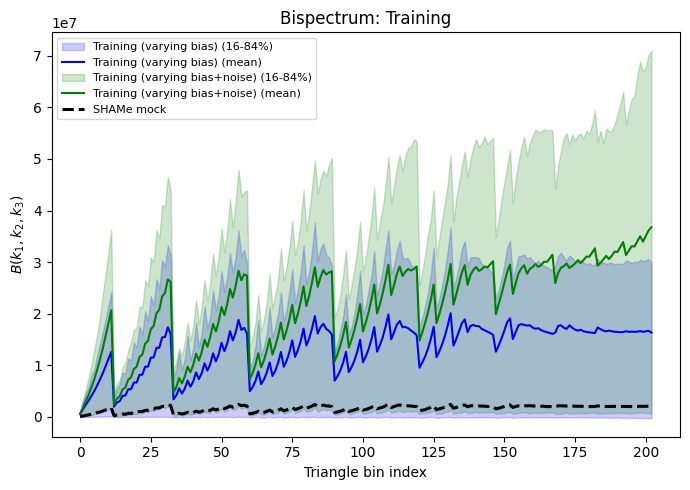

In [22]:
x_bispec = np.arange(len(mean_bispec_tv))
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, x_bispec, mean_bispec_tv, p16_bispec_tv, p84_bispec_tv,
          COLOR_VARYING_BIAS, 'Training (varying bias)')
plot_fill(ax, x_bispec, mean_bispec_tv_noise, p16_bispec_tv_noise, p84_bispec_tv_noise,
          COLOR_VARYING_BIAS_NOISE, 'Training (varying bias+noise)')
ax.plot(np.arange(len(y_shame_bispec)), y_shame_bispec, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'Bispectrum: Training', 'Triangle bin index', r'$B(k_1, k_2, k_3)$',
          xlog=False, ylog=False)
plt.tight_layout()
plt.show()

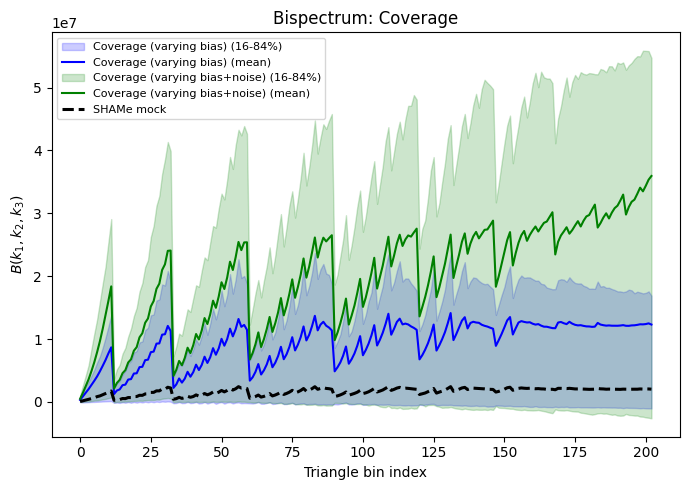

In [23]:
x_bispec_cov = np.arange(len(mean_bispec_cv))
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, x_bispec_cov, mean_bispec_cv, p16_bispec_cv, p84_bispec_cv,
          COLOR_VARYING_BIAS, 'Coverage (varying bias)')
plot_fill(ax, x_bispec_cov, mean_bispec_cv_noise, p16_bispec_cv_noise, p84_bispec_cv_noise,
          COLOR_VARYING_BIAS_NOISE, 'Coverage (varying bias+noise)')
ax.plot(np.arange(len(y_shame_bispec)), y_shame_bispec, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'Bispectrum: Coverage', 'Triangle bin index', r'$B(k_1, k_2, k_3)$',
          xlog=False, ylog=False)
plt.tight_layout()
plt.show()

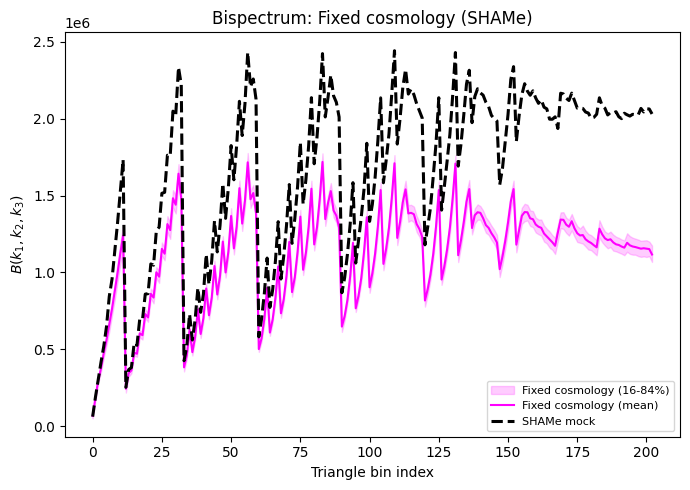

In [24]:
x_bispec_sp = np.arange(len(mean_bispec_sp))
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, x_bispec_sp, mean_bispec_sp, p16_bispec_sp, p84_bispec_sp,
          COLOR_FIXED_COSMO, 'Fixed cosmology')
ax.plot(np.arange(len(y_shame_bispec)), y_shame_bispec, color='black', linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label='SHAMe mock')
format_ax(ax, 'Bispectrum: Fixed cosmology (SHAMe)', 'Triangle bin index', r'$B(k_1, k_2, k_3)$',
          xlog=False, ylog=False)
plt.tight_layout()
plt.show()